In [2]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from ham_data import *
params = load_params("params.yaml")
# Define system parameters (in GHz)
EL = params["EL"]  # Inductive energy
EJ = params["EJ"]  # Josephson energy
EC_phi = params["EC_phi"]  # Phi mode charging energy
EC_theta = params["EC_theta"]  # Theta mode charging energy

# Compute derived parameters
E_CJ = 2 * EC_phi
E_C = 2 / (1 / EC_theta - 1 / EC_phi)

# Create the grid for the phi coordinate
phi_grid = scq.Grid1d(params["phi_range"][0], params["phi_range"][1], params["phi_cut"])

# Initialize the Zero-Pi qubit system
zero_pi = scq.ZeroPi(
    grid=phi_grid,
    EJ=EJ,
    EL=EL,
    ECJ=E_CJ,
    EC=E_C,
    dEJ=params["dEJ"],
    ng=params["ng"],
    flux=params["flux"],
    ncut=params["n_cut"],
    truncated_dim=params["truc1"],
)
spec_data = zero_pi.get_spectrum_vs_paramvals("flux", [0] + list(np.logspace(-6, -1, 101)), 
                evals_count=6, num_cpus=4, subtract_ground=True)

Parallel computation of eigensystems [num_cpus=4]

In [14]:
print(np.shape(np.array(spec_data.param_vals)))
print(np.shape(np.array(spec_data.energy_table)))

(102,)
(102, 6)


In [ ]:
data = np.load("data/data_flux_derivative_eval_300_cpu_100.npz")
flux = data["param_vals"]
energy_table = data["energy_table"]

n_ev_plot = 11  # Number of energy levels to plot

In [ ]:
# x = np.array(spec_data.param_vals)
# y = np.array(spec_data.energy_table)

# x = np.array(flux)
# y = np.array(energy_table)

# dx = np.diff(x)
# dy = np.diff(y, axis=0)
# dydx = dy
# for i in range(dy.shape[1]):
#     dydx[:,i]/=dx
# ddyddx = np.diff(dydx, axis=0)
# for i in range(ddyddx.shape[1]):
#     ddyddx[:,i]/=dx[:-1]

In [ ]:

x = np.asarray(flux)              # (N,)
y = np.asarray(energy_table)      # (N, M)

dx = np.diff(x)                   # (N-1,)
dy = np.diff(y, axis=0)           # (N-1, M)

dydx = dy / dx[:, None]           # (N-1, M)
x_mid = 0.5 * (x[1:] + x[:-1])    # (N-1,)

d2ydx2 = np.diff(dydx, axis=0) / np.diff(x_mid)[:, None]  # (N-2, M)
x_mid2 = 0.5 * (x_mid[1:] + x_mid[:-1])                   # (N-2,)


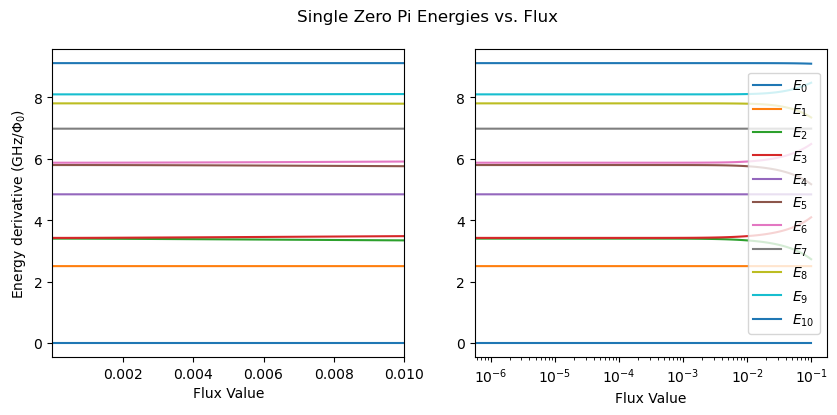

In [25]:
f, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
for i in range(n_ev_plot):
    for iax in range(2):
            p = ax[iax]
            p.plot(x, y[:, i], label=r"$E_{" + f"{i}" + r"}$")
            if iax == 1:
                p.set_xscale("log")

ax[0].set_ylabel("Energy derivative (GHz/$\Phi_0$)")
ax[1].set_xlabel("Flux Value")
ax[0].set_xlabel("Flux Value")
ax[0].set_xlim(0, 0.01)
ax[0].set_xlim(1e-06, 0.01)
plt.suptitle("Single Zero Pi Energies vs. Flux")
plt.legend();

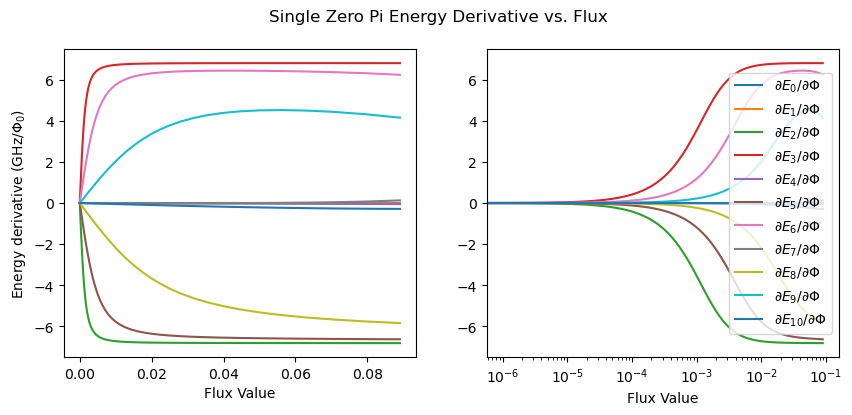

In [27]:
f2, ax2 = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
for i in range(n_ev_plot):
    for iax in range(2):
            p = ax2[iax]
            # p.plot(x[:], dydx[:, i], label=r"$\partial E_{" + f"{i}" + r"}/\partial \Phi$")
            p.plot(x[:-1], dydx[:, i], label=r"$\partial E_{" + f"{i}" + r"}/\partial \Phi$")
            if iax == 1:
                p.set_xscale("log")

ax2[0].set_ylabel("Energy derivative (GHz/$\Phi_0$)")
ax2[1].set_xlabel("Flux Value")
ax2[0].set_xlabel("Flux Value")
plt.suptitle("Single Zero Pi Energy Derivative vs. Flux")
plt.legend();

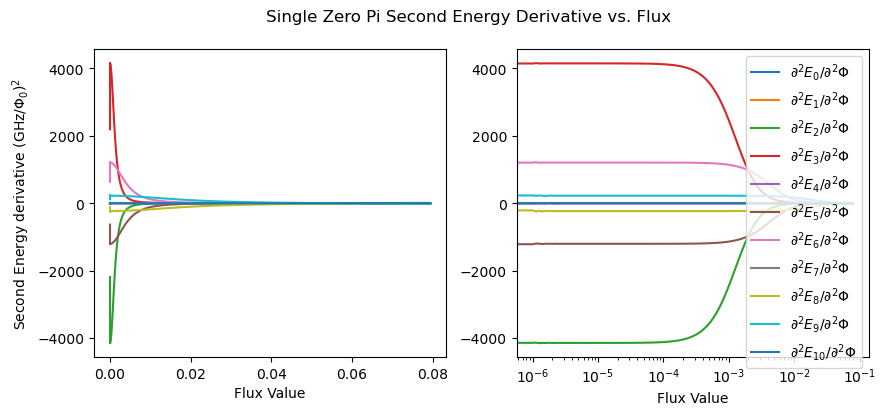

In [29]:

f2, ax2 = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
for i in range(n_ev_plot):
    for iax in range(2):
            p = ax2[iax]
            # p.plot(x[:], ddydx2[:,i], label=r"$\partial^2 E_{" + f"{i}" + r"}/\partial^2 \Phi$")
            p.plot(x[:-2], ddyddx[:,i], label=r"$\partial^2 E_{" + f"{i}" + r"}/\partial^2 \Phi$")
            if iax == 1:
                p.set_xscale("log")

ax2[0].set_ylabel("Second Energy derivative (GHz/$\Phi_0)^2$")
ax2[1].set_xlabel("Flux Value")
ax2[0].set_xlabel("Flux Value")
plt.suptitle("Single Zero Pi Second Energy Derivative vs. Flux")
plt.legend();

# Relative Magnitudes

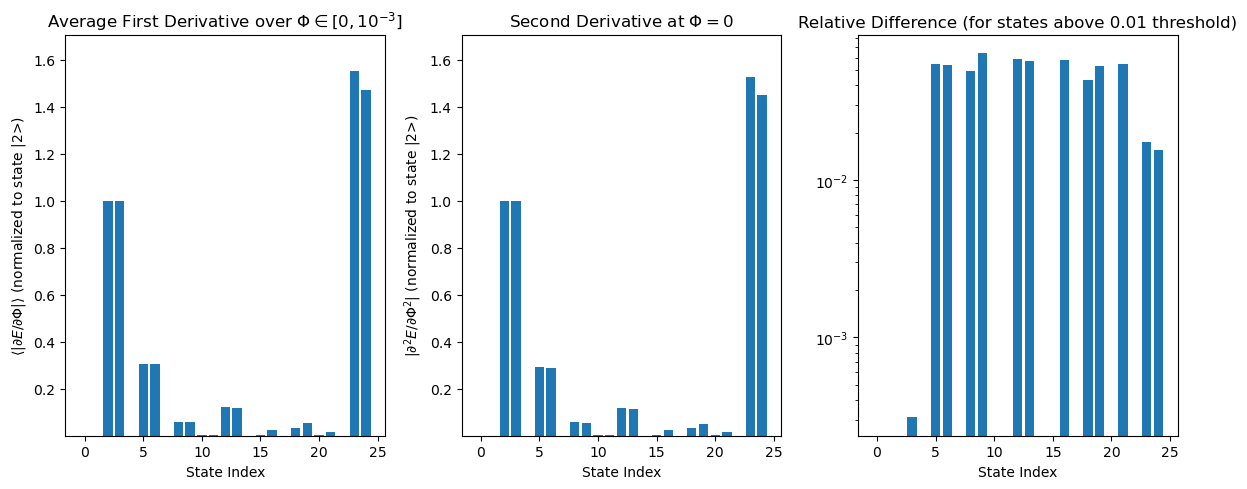

In [ ]:
avg_range = x[:-1] <= 1e-03
avg_deriv = np.mean(np.abs(dydx[avg_range,:]), axis=0)
second_deriv = ddyddx[0,:]

# Normalize to make state |2> value 1
avg_deriv /= avg_deriv[2]
second_deriv /= second_deriv[2]
thresh = 1e-02
above_thresh = np.logical_or(np.abs(avg_deriv) > thresh, np.abs(second_deriv) > thresh) 

state_idx = np.arange(dydx.shape[1])
n_ev_plot = 25  # Number of energy levels to plot
f, ax = plt.subplots(figsize=(12, 5), ncols=3)
yrange = (1e-06, max(np.max(np.abs(avg_deriv[:n_ev_plot]))*1.1, np.max(np.abs(second_deriv[:n_ev_plot]))*1.1))
ax[0].bar(state_idx[:n_ev_plot], np.abs(avg_deriv[:n_ev_plot]));
ax[1].bar(state_idx[:n_ev_plot], np.abs(second_deriv[:n_ev_plot]));
rel_diff = np.abs(np.abs(second_deriv[:n_ev_plot]) - np.abs(avg_deriv[:n_ev_plot]))/ (np.abs(avg_deriv[:n_ev_plot]) + 1e-12)
rel_diff[np.logical_not(above_thresh[:n_ev_plot])] = 0.0
ax[2].bar(state_idx[:n_ev_plot], rel_diff);
for i in range(2):
    ax[i].set_ylim(*yrange)
ax[2].set_yscale("log")
ax[0].set_xlabel("State Index")
ax[0].set_ylabel(r"$\langle |\partial E/\partial \Phi| \rangle$ (normalized to state |2>)")
ax[0].set_title(r"Average First Derivative over $\Phi \in [0, 10^{-3}]$")
ax[1].set_xlabel("State Index")
ax[1].set_ylabel(r"$|\partial^2 E/\partial \Phi^2|$ (normalized to state |2>)")
ax[1].set_title(r"Second Derivative at $\Phi=0$")
ax[2].set_xlabel("State Index")
ax[2].set_title(r"Relative Difference (for states above 0.01 threshold)")
plt.tight_layout();


# Wide View

In [ ]:
spec_data_wide = zero_pi.get_spectrum_vs_paramvals("flux", 
    [0] + list(np.logspace(-6, -1, 101)) + list(np.linspace(1e-01, 0.5, 50)), 
    evals_count=6, num_cpus=4, subtract_ground=True)

NameError: name 'zero_pi' is not defined

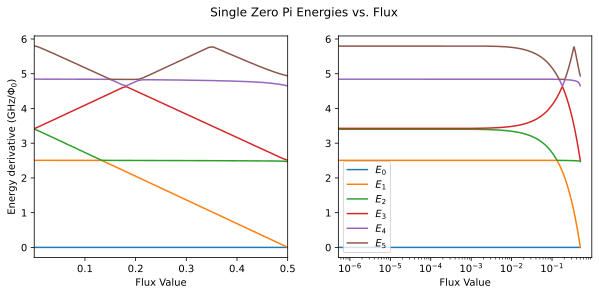

In [ ]:
f, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
for i in range(dy.shape[1]):
    for iax in range(2):
            p = ax[iax]
            p.plot(spec_data_wide.param_vals, spec_data_wide.energy_table[:, i], label=r"$E_{" + f"{i}" + r"}$")
            if iax == 1:
                p.set_xscale("log")

ax[0].set_ylabel("Energy derivative (GHz/$\Phi_0$)")
ax[1].set_xlabel("Flux Value")
ax[0].set_xlabel("Flux Value")
ax[0].set_xlim(0, 0.5)
ax[0].set_xlim(1e-06, 0.5)
plt.suptitle("Single Zero Pi Energies vs. Flux")
plt.legend();